**Step 1: Try Improving Model**

**Change features**

In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

In [3]:
#Try adding more columns:
df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Fare"]]
# 🧠 Why this helps:
# More data → better learning
df["Sex"]=df["Sex"].astype(str).str.lower().str.strip()
df["Sex"]=df["Sex"].map({"male":0,"female":1})
#to handle missing values
df = df.fillna(df.mean(numeric_only=True))
df.head()


,Survived,Pclass,Sex,Age,SibSp,Fare
0,0,3,0,22.0,1,7.2500
1,1,1,1,38.0,1,71.2833
2,1,3,1,26.0,0,7.9250
3,1,1,1,35.0,1,53.1000
4,0,3,0,35.0,0,8.0500


In [4]:
#split
from sklearn.model_selection import train_test_split
X = df[["Pclass", "Sex", "Age", "SibSp", "Fare"]]#inputs
y = df["Survived"]#target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
## Train
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
#### PREDICT
predictions = model.predict(X_test)
#predictions[:10]
### Check Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,predictions)
print(accuracy)

0.8156424581005587


**STEP 2: Try Another Model (Decision Tree)**

In [5]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)  
#training the model
# X_train = input data (features)
# y_train = output (Survived or not)
## Decision Tree:--- It works like a series of questions
 ## Is passenger female?
   # YES → survived
   # NO →
   #     Is age < 10?
   #         YES → survived
   #         NO → not survived

## Predict
y_pred = model.predict(X_test)


🚀 Step-by-step flow
🔹 1. Train model
model.fit(X_train, y_train)
👉 Model learns from:
X_train (data)
y_train (correct answers)
2. Predict
y_pred = model.predict(X_test)
👉 Model sees:
X_test (new data)
👉 And guesses:
y_pred (predictions)
3. Compare
accuracy_score(y_test, y_pred)
Compare:
y_test (real answers)
y_pred (model answers)

Study material → X_train + y_train
Exam questions → X_test
Correct answers → y_test
Your answers → y_pred


In [6]:
## Check Accuracy 
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


0.7597765363128491


** **Step 3**
## Model Comparison

- Logistic Regression Accuracy: 0.75
- Decision Tree Accuracy: 0.75
**

Step 4 :-- to check the output who has high survival

MOST IMPORTANT (see relationships)

In [7]:
#✅ Compare survival vs gende
df.groupby("Sex")["Survived"].mean()
## therefore , in output u see that female survived more

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

In [8]:
## ✅ Compare survival vs class
df.groupby("Pclass")["Survived"].mean() 
#🧠 Meaning:
# 👉 Rich people survived more

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

**STEP 5 (OPTIONAL)**

<Axes: xlabel='Sex', ylabel='Survived'>

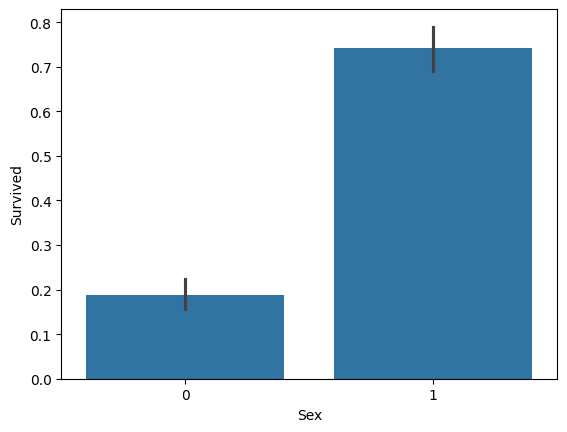

In [9]:
##Use plots
import seaborn as sns
sns.barplot(x="Sex", y="Survived", data=df)
## male:0 , female:1

**Final Answer**

****- Females survived more than males- 1st class passengers survived more- Lower class had lower survival****
